In [3]:
import os
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import torch
from fourm.vq.vqvae import DiVAE
import torchvision.transforms.functional as TF
device = "cuda"

In [4]:
tok_edge_fourm = DiVAE.from_pretrained('EPFL-VILAB/4M_tokenizers_edge_8k_224-512').eval().to(device)

/home/tmaillar/.local/lib/python3.10/site-packages/fourm/vq/scheduling/diffusion_pipeline.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


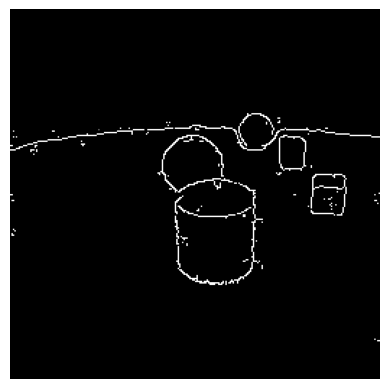

In [5]:
canny = np.load("/scratch/tmaillar/canny/train/tok_canny@256/00000.npy") # 00000 - 49999
AUG_IDX = 0 # 0 - 9

cannny_tensor = torch.tensor(canny[AUG_IDX], dtype=torch.long).reshape(1, 16, 16).to(device)
with torch.no_grad():
    reconst_4m = tok_edge_fourm.decode_tokens(cannny_tensor, image_size=256)
    
# Visualize
reconst_np = reconst_4m.squeeze().cpu().numpy()
plt.imshow(reconst_np, cmap='gray')
plt.axis('off')
plt.show()
